# R(2) normal/opposite-parity peak-height ratio vs laser power

This notebook reuses the `R(2) F1'=7/2 F'=3` conditions from
`r2_opposite_parity_retention_initial_pop.ipynb`, but instead of plotting a
single frequency scan it scans laser power and extracts the local peak heights
near:

- the normal addressed-parity direct peak, `P'=-, |mF|=1`, near 0 MHz;
- the retained opposite-parity direct peak, `P'=+, |mF|=1`, near 29 MHz.

The plotted ratio is `opposite-parity peak height / normal peak height`.

To keep the power scan reasonably fast, each power is scanned only in small
detuning windows around the two direct peaks. Increase `PEAK_WINDOW_MHZ` or
decrease `PEAK_DETUNING_STEP_MHZ` if a peak is clipped or under-resolved.

In [1]:
from __future__ import annotations

import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.constants as cst
import sympy as smp

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions
from centrex_tlf.lindblad.parameters import LindbladParameters
from centrex_tlf.lindblad.plan_static import prepare_lindblad_problem
from centrex_tlf.utils import population
from centrex_tlf.utils.rabi import (
    power_to_intensity_rectangular_beam,
    power_to_rabi_rectangular_beam,
)

plt.rcParams.update({"font.size": 14})

GAMMA = getattr(hamiltonian, "Γ")

## Configuration

In [2]:
transition = transitions.R2_F1_7o2_F3

E_FIELD = np.array([0.0, 0.0, 200.0])  # V/cm, along Z
B_FIELD = np.array([0.0, 0.0, 1e-5])  # G, tiny quantization field

BEAM_WX = 0.02  # m
BEAM_WY = 0.02  # m
VELOCITY = 184.0  # m/s
INTERACTION_LENGTH = 0.02  # m
T_END = INTERACTION_LENGTH / VELOCITY

# Geometric spacing is convenient because saturation/power broadening can span decades.
POWER_SCAN_MW = np.geomspace(0.1, 200.0, 25)
POWER_SCAN_W = POWER_SCAN_MW * 1e-3

# Local windows around the normal and opposite-parity peaks.
PEAK_WINDOW_MHZ = 6.0
PEAK_DETUNING_STEP_MHZ = 0.5

SCAN_SAVEAT = np.linspace(0.0, T_END, 801)
SCAN_THREADS = None  # None lets the Rust backend choose; set an int to cap cores.

INITIAL_F1 = 5 / 2
INITIAL_F = 2
INITIAL_MF = 0

# These are kept from the original notebook for reference and optional extensions.
TRANSVERSE_VELOCITY_SIGMA = 1.0  # m/s
OPTICAL_FREQUENCY_HZ = 1.1e15
OPTICAL_WAVELENGTH_M = cst.c / OPTICAL_FREQUENCY_HZ
DOPPLER_SIGMA_MHZ = OPTICAL_FREQUENCY_HZ * TRANSVERSE_VELOCITY_SIGMA / cst.c / 1e6

reference_intensity = power_to_intensity_rectangular_beam(60e-3, BEAM_WX, BEAM_WY)

config = {
    "transition": transition.name,
    "J_ground": transition.J_ground,
    "J_excited": transition.J_excited,
    "F1_excited": str(smp.Rational(transition.F1_excited).limit_denominator()),
    "F_excited": transition.F_excited,
    "addressed_excited_parity": "+" if transition.P_excited == 1 else "-",
    "opposite_excited_parity": "+" if -transition.P_excited == 1 else "-",
    "initial_state": f"X, J=2, F1=5/2, F=2, mF={INITIAL_MF}",
    "electric_field_V_per_cm": E_FIELD.tolist(),
    "polarization": "X",
    "beam_area_cm2": (BEAM_WX * 100) * (BEAM_WY * 100),
    "reference_60mW_intensity_mW_per_cm2": reference_intensity * 0.1,
    "velocity_m_per_s": VELOCITY,
    "interaction_time_us": T_END * 1e6,
    "power_scan_mW": POWER_SCAN_MW.tolist(),
    "peak_window_MHz": PEAK_WINDOW_MHZ,
    "peak_detuning_step_MHz": PEAK_DETUNING_STEP_MHZ,
    "doppler_sigma_MHz": float(DOPPLER_SIGMA_MHZ),
    "optical_wavelength_nm": float(OPTICAL_WAVELENGTH_M * 1e9),
}
config

{'transition': "R(2) F1'=7/2 F'=3",
 'J_ground': 2,
 'J_excited': 3,
 'F1_excited': '7/2',
 'F_excited': 3,
 'addressed_excited_parity': '-',
 'opposite_excited_parity': '+',
 'initial_state': 'X, J=2, F1=5/2, F=2, mF=0',
 'electric_field_V_per_cm': [0.0, 0.0, 200.0],
 'polarization': 'X',
 'beam_area_cm2': 4.0,
 'reference_60mW_intensity_mW_per_cm2': 15.0,
 'velocity_m_per_s': 184.0,
 'interaction_time_us': 108.69565217391305,
 'power_scan_mW': [0.1,
  0.13725965927377423,
  0.18840214063952596,
  0.2586001363063102,
  0.35495366597555705,
  0.4872081924978203,
  0.668740304976422,
  0.9179106640370356,
  1.2599210498948734,
  1.7293633402042619,
  2.373718228369931,
  3.258157552380037,
  4.47213595499958,
  6.1384385740923735,
  8.425599871529116,
  11.56494967543242,
  15.874010519682,
  21.7886127523986,
  29.906975624424415,
  41.05021284117567,
  56.345382276956855,
  77.33947972985649,
  106.15590636131074,
  145.70923537052198,
  200.0],
 'peak_window_MHz': 6.0,
 'peak_detunin

## Nearby excited-state levels

Zero detuning is defined by the X-driven addressed-parity `P'=-, |mF|=1`
dressed pair. The retained opposite-parity direct pair is identified from
the same `F'=3` ladder.

In [3]:
def _state_label(state: states.CoupledState) -> str:
    qn = state.largest
    f1 = smp.S(str(qn.F1), rational=True) if qn.F1 is not None else None
    parity = "+" if qn.P == 1 else "-"
    return f"J={qn.J}, F1={f1}, F={qn.F}, mF={qn.mF}, P={parity}"


def excited_level_offsets() -> list[dict[str, float | str | int]]:
    selector = states.QuantumSelector(
        electronic=states.ElectronicState.B,
        J=transition.J_excited,
        P=[transition.P_excited, -transition.P_excited],
    )
    approx_states = list(states.generate_coupled_states_B(selector))
    reduced = hamiltonian.generate_reduced_B_hamiltonian(
        approx_states,
        E=E_FIELD,
        B=B_FIELD,
        Jmin=transition.J_excited,
        Jmax=transition.J_excited + 2,
    )

    reference_indices = [
        i
        for i, state in enumerate(reduced.QN_basis)
        if state.largest.F1 == transition.F1_excited
        and state.largest.F == transition.F_excited
        and abs(state.largest.mF) == 1
        and state.largest.P == transition.P_excited
    ]
    if len(reference_indices) != 2:
        raise ValueError(f"Expected two mF=+/-1 reference states, got {reference_indices}")

    ref_energy = float(np.mean([np.real(reduced.H[idx, idx]) for idx in reference_indices]))

    rows = []
    for i, state in enumerate(reduced.QN_basis):
        qn = state.largest
        delta_mhz = (float(np.real(reduced.H[i, i])) - ref_energy) / (2 * np.pi * 1e6)
        rows.append(
            {
                "state": _state_label(state),
                "F1": str(smp.S(str(qn.F1), rational=True)),
                "F": int(qn.F),
                "mF": int(qn.mF),
                "parity": "+" if qn.P == 1 else "-",
                "delta_MHz": delta_mhz,
                "abs_delta_MHz": abs(delta_mhz),
            }
        )
    return sorted(rows, key=lambda row: row["abs_delta_MHz"])


level_offsets = excited_level_offsets()
f3_rows = [
    row
    for row in level_offsets
    if row["F1"] == str(smp.Rational(transition.F1_excited).limit_denominator())
    and row["F"] == transition.F_excited
]

for row in f3_rows:
    print(f"{row['delta_MHz']:12.6f} MHz  {row['state']}")

    0.000001 MHz  J=3, F1=7/2, F=3, mF=-1, P=-
   -0.000001 MHz  J=3, F1=7/2, F=3, mF=1, P=-
   12.026306 MHz  J=3, F1=7/2, F=3, mF=0, P=-
  -14.214154 MHz  J=3, F1=7/2, F=3, mF=-2, P=-
  -14.214157 MHz  J=3, F1=7/2, F=3, mF=2, P=-
   17.019996 MHz  J=3, F1=7/2, F=3, mF=0, P=+
  -28.514876 MHz  J=3, F1=7/2, F=3, mF=-3, P=-
  -28.514881 MHz  J=3, F1=7/2, F=3, mF=3, P=-
   29.031699 MHz  J=3, F1=7/2, F=3, mF=1, P=+
   29.031701 MHz  J=3, F1=7/2, F=3, mF=-1, P=+
   43.202108 MHz  J=3, F1=7/2, F=3, mF=2, P=+
   43.202111 MHz  J=3, F1=7/2, F=3, mF=-2, P=+
   57.430124 MHz  J=3, F1=7/2, F=3, mF=3, P=+
   57.430129 MHz  J=3, F1=7/2, F=3, mF=-3, P=+


c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [24, 25, 36, 37, 38, 39, 54, 55]. Overlaps: [0.4908904035370138, 0.49068535899076277, 0.49089040347091345, 0.49068535903278154, 0.492017513739754, 0.4919882163394565, 0.49201751371476454, 0.4919882163148293]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


## Build retained opposite-parity OBE system

In [4]:
ground_main = 1 * next(
    iter(
        states.generate_coupled_states_X(
            states.QuantumSelector(
                electronic=states.ElectronicState.X,
                J=transition.J_ground,
                F1=INITIAL_F1,
                F=INITIAL_F,
                mF=INITIAL_MF,
                P=transition.P_ground,
            )
        )
    )
)

excited_main = 1 * next(
    iter(
        states.generate_coupled_states_B(
            states.QuantumSelector(
                electronic=states.ElectronicState.B,
                J=transition.J_excited,
                F1=transition.F1_excited,
                F=transition.F_excited,
                mF=1,
                P=transition.P_excited,
            )
        )
    )
)

transition_selectors = couplings.generate_transition_selectors(
    transitions=[transition],
    polarizations=[[couplings.polarization_X]],
    ground_mains=[ground_main],
    excited_mains=[excited_main],
)

system = lindblad.generate_OBE_system_transitions(
    [transition],
    transition_selectors,
    qn_compact=True,
    E=E_FIELD,
    B=B_FIELD,
    retain_opposite_parity_levels=True,
    method="matrix",
)

retained = [
    _state_label(state)
    for state in system.excited
    if state.largest.J == transition.J_excited
    and state.largest.F1 == transition.F1_excited
    and state.largest.F == transition.F_excited
]
print(f"{len(system.QN)} total levels, {len(retained)} retained F'=3 levels")
for state in retained:
    print("  ", state)

c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [0, 1, 12, 13]. Overlaps: [0.49174457879912414, 0.49163644217435554, 0.49174457871440175, 0.49163644220088737]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(
c:\Users\ogras\Documents\GitHub\CeNTREX-TlF\.venv\Lib\site-packages\centrex_tlf\states\find_states.py:564: UserWarning: Low overlap detected for approximate states at indices [8, 10]. Overlaps: [0.43344884338308637, 0.4334488177466614]. The approximate states may not be well-represented in the eigenstate basis.
  indices = find_exact_states_indices(


38 total levels, 14 retained F'=3 levels
   J=3, F1=7/2, F=3, mF=-3, P=-
   J=3, F1=7/2, F=3, mF=-3, P=+
   J=3, F1=7/2, F=3, mF=-2, P=-
   J=3, F1=7/2, F=3, mF=-2, P=+
   J=3, F1=7/2, F=3, mF=-1, P=-
   J=3, F1=7/2, F=3, mF=-1, P=+
   J=3, F1=7/2, F=3, mF=0, P=-
   J=3, F1=7/2, F=3, mF=0, P=+
   J=3, F1=7/2, F=3, mF=1, P=-
   J=3, F1=7/2, F=3, mF=1, P=+
   J=3, F1=7/2, F=3, mF=2, P=-
   J=3, F1=7/2, F=3, mF=2, P=+
   J=3, F1=7/2, F=3, mF=3, P=-
   J=3, F1=7/2, F=3, mF=3, P=+


## Scan helpers

In [5]:
def parameter_values(
    system: lindblad.OBESystem,
    power_w: float,
) -> tuple[LindbladParameters, float]:
    main_coupling = abs(system.couplings[0].main_coupling)
    rabi_rate = power_to_rabi_rectangular_beam(
        power_w,
        main_coupling,
        BEAM_WX,
        BEAM_WY,
    )

    values = {str(symbol): 0.0 for symbol in system.H_symbolic.free_symbols}
    for symbol in system.coupling_symbols:
        values[str(symbol)] = rabi_rate
    for symbol_group in system.polarization_symbols:
        symbols = symbol_group if isinstance(symbol_group, (list, tuple)) else [symbol_group]
        for symbol in symbols:
            values[str(symbol)] = 1.0

    params = LindbladParameters()
    for name, value in values.items():
        params.real(name, float(value))
    return params, rabi_rate


def index_sets(system: lindblad.OBESystem) -> dict[str, list[int]]:
    ground = []
    excited = []
    addressed_f3 = []
    opposite_f3 = []
    for idx, state in enumerate(system.QN):
        qn = state.largest
        if qn.electronic_state == states.ElectronicState.X:
            ground.append(idx)
        elif qn.electronic_state == states.ElectronicState.B:
            excited.append(idx)
            is_f3 = (
                qn.J == transition.J_excited
                and qn.F1 == transition.F1_excited
                and qn.F == transition.F_excited
            )
            if is_f3 and qn.P == transition.P_excited:
                addressed_f3.append(idx)
            if is_f3 and qn.P == -transition.P_excited:
                opposite_f3.append(idx)
    return {
        "ground": ground,
        "excited": excited,
        "addressed_f3": addressed_f3,
        "opposite_f3": opposite_f3,
    }


def f3_line_groups(max_abs_mhz: float = 80.0) -> list[dict[str, object]]:
    groups: dict[tuple[str, int], list[dict[str, float | str | int]]] = {}
    for row in f3_rows:
        if row["abs_delta_MHz"] > max_abs_mhz:
            continue
        key = (str(row["parity"]), abs(int(row["mF"])))
        groups.setdefault(key, []).append(row)

    line_groups = []
    for (parity, abs_mf), rows in sorted(groups.items(), key=lambda item: (item[0][0], item[0][1])):
        detuning_mhz = float(np.mean([float(row["delta_MHz"]) for row in rows]))
        mfs = sorted(int(row["mF"]) for row in rows)
        if abs_mf == 0:
            mf_label = "mF=0"
        else:
            mf_label = f"mF=+/-{abs_mf}"

        directly_driven = abs_mf == 1
        if directly_driven and parity == ("+" if transition.P_excited == 1 else "-"):
            role = "X-driven addressed parity"
        elif directly_driven:
            role = "X-driven opposite parity"
        else:
            role = "nearby, not driven from initial mF=0 by ideal X"

        line_groups.append(
            {
                "detuning_MHz": detuning_mhz,
                "label": f"P'={parity}, {mf_label}: {role}",
                "parity": parity,
                "abs_mF": abs_mf,
                "mF_values": mfs,
                "directly_driven": directly_driven,
            }
        )
    return sorted(line_groups, key=lambda group: float(group["detuning_MHz"]))


def add_f3_level_markers(ax, max_abs_mhz: float = 80.0) -> None:
    for group in f3_line_groups(max_abs_mhz=max_abs_mhz):
        directly_driven = bool(group["directly_driven"])
        parity = group["parity"]
        color = "C3" if parity == "+" else "C2"
        detuning_mhz = float(group["detuning_MHz"])
        ax.axvline(
            detuning_mhz,
            color=color,
            lw=2.2 if directly_driven else 1.3,
            ls="-" if directly_driven else "--",
            alpha=0.95 if directly_driven else 0.5,
            zorder=1,
        )


def photon_count_frequency_scan(
    system: lindblad.OBESystem,
    power_w: float,
    detuning_mhz: np.ndarray,
    density_matrix: np.ndarray,
    threads: int | None = SCAN_THREADS,
) -> dict[str, object]:
    params, rabi_rate = parameter_values(system, power_w)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    excited_indices = index_sets(system)["excited"]
    photon_integral_weights = [(int(idx), float(GAMMA)) for idx in excited_indices]
    delta_symbol = getattr(transition_selectors[0], "δ")

    result = lindblad.grid_scan(
        prepared,
        density_matrix,
        (0.0, T_END),
        scan={delta_symbol: 2 * np.pi * 1e6 * detuning_mhz},
        solver="dopri5",
        execution_mode="expanded_sparse",
        output="photon_integral",
        output_when="saveat",
        integral_weights=photon_integral_weights,
        saveat=SCAN_SAVEAT,
        dt=2e-9,
        reltol=1e-7,
        abstol=1e-9,
        parallel=True,
        threads=threads,
        collect_stats=True,
    )

    photons = result.values.reshape(detuning_mhz.size, -1)[:, -1]
    return {
        "detuning_MHz": detuning_mhz,
        "photons": photons,
        "rabi_rate": rabi_rate,
        "result": result,
    }

## Initial population

This uses the weighted initial population from the earlier notebook:
`2/3` in `F=2, mF=0`, and `1/9` in each of `F=3, mF=-1,0,+1`.

The helper below uses `population.generate_uniform_population_state_indices(..., weights=...)`
if your local branch already has the optional `weights` argument. Otherwise it falls
back to the same implementation locally so the notebook remains runnable before
installing that change.

In [6]:
populated_states = [
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F, mF=INITIAL_MF),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=-1),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=0),
    states.QuantumSelector(J=2, F1=INITIAL_F1, F=INITIAL_F + 1, mF=+1),
]
weights_per_selector = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9], dtype=float)

selected_index_groups = [
    np.asarray(selector.get_indices(system.QN), dtype=int) for selector in populated_states
]
indices = np.concatenate(selected_index_groups)
weights = np.concatenate(
    [
        np.full(group.size, selector_weight / group.size)
        for group, selector_weight in zip(selected_index_groups, weights_per_selector)
    ]
)


def population_state_indices(
    state_indices: np.ndarray,
    levels: int,
    weights: np.ndarray | None = None,
) -> np.ndarray:
    signature = inspect.signature(population.generate_uniform_population_state_indices)
    if weights is None:
        return population.generate_uniform_population_state_indices(state_indices, levels)
    if "weights" in signature.parameters:
        return population.generate_uniform_population_state_indices(
            state_indices,
            levels,
            weights=weights,
        )

    state_indices = np.asarray(state_indices, dtype=int)
    weights = np.asarray(weights, dtype=float)
    if state_indices.size != weights.size:
        raise ValueError("state_indices and weights must have the same length")
    if np.any(weights < 0) or not np.all(np.isfinite(weights)) or np.sum(weights) <= 0:
        raise ValueError("weights must be finite, non-negative, and sum to a positive value")

    rho = np.zeros((levels, levels), dtype=np.complex128)
    np.add.at(rho, (state_indices, state_indices), weights)
    return rho / np.trace(rho)


density_matrix = population_state_indices(indices, len(system.QN), weights=weights)

print("Selected indices:", indices)
print("Selected weights:", weights)
print("Trace:", np.trace(density_matrix))
print("Nonzero diagonal entries:")
for idx in np.flatnonzero(np.abs(np.diag(density_matrix)) > 0):
    print(f"  {idx:3d}: {np.real(density_matrix[idx, idx]):.6f}  {_state_label(system.QN[idx])}")

Selected indices: [11 16 17 18]
Selected weights: [0.66666667 0.11111111 0.11111111 0.11111111]
Trace: (1.0000000000000002+0j)
Nonzero diagonal entries:
   11: 0.666667  J=2, F1=5/2, F=2, mF=0, P=+
   16: 0.111111  J=2, F1=5/2, F=3, mF=-1, P=+
   17: 0.111111  J=2, F1=5/2, F=3, mF=0, P=+
   18: 0.111111  J=2, F1=5/2, F=3, mF=1, P=+


## Define normal and opposite-parity peak windows

In [7]:
def directly_driven_peak_centers() -> dict[str, float]:
    addressed_parity = "+" if transition.P_excited == 1 else "-"
    opposite_parity = "+" if -transition.P_excited == 1 else "-"
    direct_groups = [group for group in f3_line_groups() if bool(group["directly_driven"])]

    normal = next(group for group in direct_groups if group["parity"] == addressed_parity)
    opposite = next(group for group in direct_groups if group["parity"] == opposite_parity)

    return {
        "normal": float(normal["detuning_MHz"]),
        "opposite": float(opposite["detuning_MHz"]),
    }


def detuning_grid_for_peaks(
    centers: dict[str, float],
    window_mhz: float,
    step_mhz: float,
) -> np.ndarray:
    segments = []
    for center in centers.values():
        segments.append(
            np.arange(center - window_mhz, center + window_mhz + 0.5 * step_mhz, step_mhz)
        )
    # Round before unique to avoid floating-point duplicates when grids overlap.
    return np.unique(np.round(np.concatenate(segments), 9))


peak_centers = directly_driven_peak_centers()
peak_detunings_mhz = detuning_grid_for_peaks(
    peak_centers,
    window_mhz=PEAK_WINDOW_MHZ,
    step_mhz=PEAK_DETUNING_STEP_MHZ,
)

print("Peak centers:", peak_centers)
print(f"{peak_detunings_mhz.size} detuning points per power")

Peak centers: {'normal': 0.0, 'opposite': 29.031699878166535}
50 detuning points per power


## Run power scan and extract local peak heights

`edge_hit=True` means the local maximum fell on the edge of one of the search
windows. If that happens, increase `PEAK_WINDOW_MHZ` and rerun.

In [8]:
def local_peak(
    detuning_mhz: np.ndarray,
    photons: np.ndarray,
    center_mhz: float,
    window_mhz: float,
) -> dict[str, float | bool]:
    mask = np.abs(detuning_mhz - center_mhz) <= window_mhz
    if not np.any(mask):
        raise ValueError(f"No detuning points found around {center_mhz:.3f} MHz")

    x = detuning_mhz[mask]
    y = photons[mask]
    local_idx = int(np.argmax(y))

    return {
        "detuning_MHz": float(x[local_idx]),
        "height": float(y[local_idx]),
        "edge_hit": bool(local_idx == 0 or local_idx == y.size - 1),
    }


power_scan_rows = []
power_scans: dict[float, dict[str, object]] = {}

for power_mw, power_w in zip(POWER_SCAN_MW, POWER_SCAN_W):
    scan = photon_count_frequency_scan(
        system,
        power_w=float(power_w),
        detuning_mhz=peak_detunings_mhz,
        density_matrix=density_matrix,
    )

    normal_peak = local_peak(
        scan["detuning_MHz"],
        scan["photons"],
        center_mhz=peak_centers["normal"],
        window_mhz=PEAK_WINDOW_MHZ,
    )
    opposite_peak = local_peak(
        scan["detuning_MHz"],
        scan["photons"],
        center_mhz=peak_centers["opposite"],
        window_mhz=PEAK_WINDOW_MHZ,
    )

    row = {
        "power_mW": float(power_mw),
        "rabi_rate_MHz": float(scan["rabi_rate"] / (2 * np.pi * 1e6)),
        "normal_peak_detuning_MHz": normal_peak["detuning_MHz"],
        "normal_peak_height": normal_peak["height"],
        "normal_peak_edge_hit": normal_peak["edge_hit"],
        "opposite_peak_detuning_MHz": opposite_peak["detuning_MHz"],
        "opposite_peak_height": opposite_peak["height"],
        "opposite_peak_edge_hit": opposite_peak["edge_hit"],
        "opposite_over_normal": opposite_peak["height"] / normal_peak["height"],
        "normal_over_opposite": normal_peak["height"] / opposite_peak["height"],
        "solver_total_seconds": scan["result"].solver_stats.get("total_seconds")
        if scan["result"].solver_stats is not None
        else None,
    }
    power_scan_rows.append(row)
    power_scans[float(power_mw)] = scan

    print(
        f"{power_mw:8.3f} mW  "
        f"Ω/2π={row['rabi_rate_MHz']:.4f} MHz  "
        f"normal={row['normal_peak_height']:.6g}  "
        f"opposite={row['opposite_peak_height']:.6g}  "
        f"opp/norm={row['opposite_over_normal']:.6g}"
    )

power_scan_df = pd.DataFrame(power_scan_rows)
power_scan_df

   0.100 mW  Ω/2π=0.0125 MHz  normal=0.0868467  opposite=0.0603233  opp/norm=0.694596
   0.137 mW  Ω/2π=0.0146 MHz  normal=0.11663  opposite=0.0815055  opp/norm=0.698835
   0.188 mW  Ω/2π=0.0172 MHz  normal=0.155404  opposite=0.109497  opp/norm=0.704595
   0.259 mW  Ω/2π=0.0201 MHz  normal=0.204901  opposite=0.145968  opp/norm=0.712384
   0.355 mW  Ω/2π=0.0236 MHz  normal=0.266419  opposite=0.19258  opp/norm=0.722848
   0.487 mW  Ω/2π=0.0276 MHz  normal=0.340134  opposite=0.250597  opp/norm=0.736759
   0.669 mW  Ω/2π=0.0323 MHz  normal=0.424196  opposite=0.320249  opp/norm=0.754955
   0.918 mW  Ω/2π=0.0379 MHz  normal=0.513857  opposite=0.399852  opp/norm=0.778139
   1.260 mW  Ω/2π=0.0444 MHz  normal=0.601354  opposite=0.48495  opp/norm=0.806431
   1.729 mW  Ω/2π=0.0520 MHz  normal=0.677484  opposite=0.568106  opp/norm=0.838553
   2.374 mW  Ω/2π=0.0609 MHz  normal=0.735253  opposite=0.640277  opp/norm=0.870826
   3.258 mW  Ω/2π=0.0714 MHz  normal=0.773893  opposite=0.694241  opp/norm=0

,power_mW,rabi_rate_MHz,normal_peak_detuning_MHz,normal_peak_height,normal_peak_edge_hit,opposite_peak_detuning_MHz,opposite_peak_height,opposite_peak_edge_hit,opposite_over_normal,normal_over_opposite,solver_total_seconds
0,0.100000,0.012502,0.0,0.086847,False,29.0317,0.060323,False,0.694596,1.439686,9.031178
1,0.137260,0.014647,0.0,0.116630,False,29.0317,0.081505,False,0.698835,1.430952,9.080296
2,0.188402,0.017160,0.0,0.155404,False,29.0317,0.109497,False,0.704595,1.419255,9.017765
3,0.258600,0.020104,0.0,0.204901,False,29.0317,0.145968,False,0.712384,1.403737,9.238622
4,0.354954,0.023553,0.0,0.266419,False,29.0317,0.192580,False,0.722848,1.383417,9.229856
5,0.487208,0.027595,0.0,0.340134,False,29.0317,0.250597,False,0.736759,1.357295,8.831308
6,0.668740,0.032329,0.0,0.424196,False,29.0317,0.320249,False,0.754955,1.324582,8.845234
7,0.917911,0.037876,0.0,0.513857,False,29.0317,0.399852,False,0.778139,1.285117,9.175364
8,1.259921,0.044375,0.0,0.601354,False,29.0317,0.484950,False,0.806431,1.240032,9.866829
9,1.729363,0.051989,0.0,0.677484,False,29.0317,0.568106,False,0.838553,1.192531,8.818784


## Plot ratio vs laser power

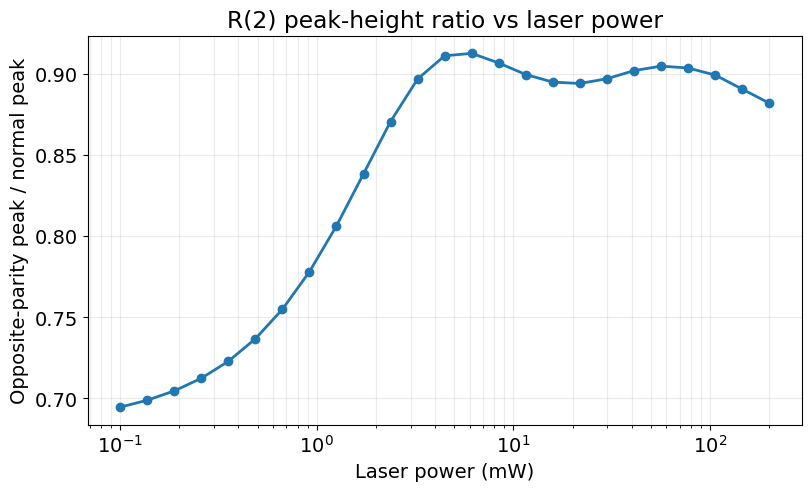

In [9]:
fig, ax = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)

ax.semilogx(
    power_scan_df["power_mW"],
    power_scan_df["opposite_over_normal"],
    "o-",
    lw=2,
)

ax.set_xlabel("Laser power (mW)")
ax.set_ylabel("Opposite-parity peak / normal peak")
ax.grid(alpha=0.25, which="both")

bad_edges = power_scan_df[
    power_scan_df["normal_peak_edge_hit"] | power_scan_df["opposite_peak_edge_hit"]
]
if not bad_edges.empty:
    ax.set_title("Warning: at least one peak hit a window edge")
else:
    ax.set_title("R(2) peak-height ratio vs laser power")

## Plot absolute peak heights

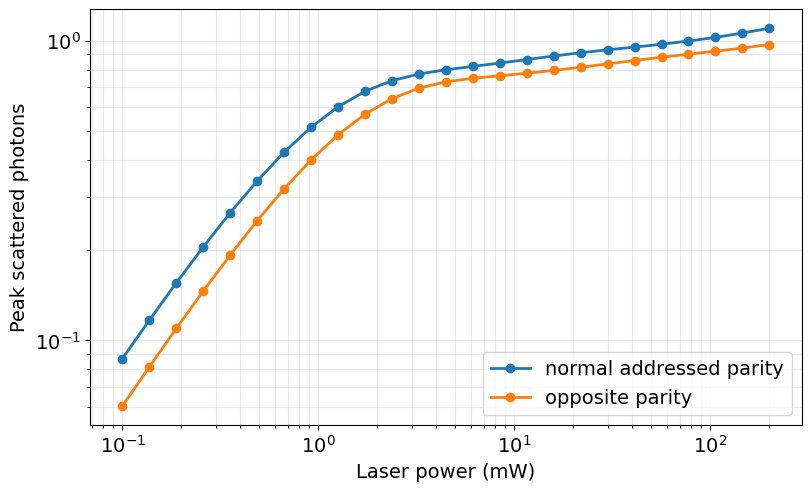

In [10]:
fig, ax = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)

ax.loglog(
    power_scan_df["power_mW"],
    power_scan_df["normal_peak_height"],
    "o-",
    lw=2,
    label="normal addressed parity",
)
ax.loglog(
    power_scan_df["power_mW"],
    power_scan_df["opposite_peak_height"],
    "o-",
    lw=2,
    label="opposite parity",
)

ax.set_xlabel("Laser power (mW)")
ax.set_ylabel("Peak scattered photons")
ax.grid(alpha=0.25, which="both")
ax.legend()

## Inspect one representative local scan

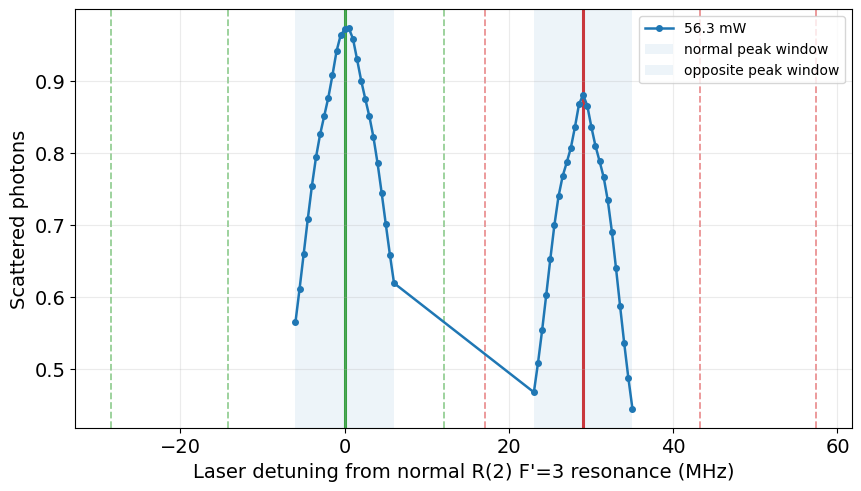

In [11]:
reference_power_mw = float(POWER_SCAN_MW[np.argmin(np.abs(POWER_SCAN_MW - 60.0))])
scan = power_scans[reference_power_mw]

fig, ax = plt.subplots(figsize=(8.5, 4.8), constrained_layout=True)

ax.plot(
    scan["detuning_MHz"],
    scan["photons"],
    "o-",
    lw=1.8,
    ms=4,
    label=f"{reference_power_mw:.1f} mW",
)
add_f3_level_markers(ax, max_abs_mhz=80.0)

for label, center in peak_centers.items():
    ax.axvspan(
        center - PEAK_WINDOW_MHZ,
        center + PEAK_WINDOW_MHZ,
        alpha=0.08,
        label=f"{label} peak window",
    )

ax.set_xlabel("Laser detuning from normal R(2) F'=3 resonance (MHz)")
ax.set_ylabel("Scattered photons")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=10)

## Optional: Doppler-convolved variant

The cells above use the zero-transverse-velocity line shape. To mimic the
convolution approach from the original notebook for every power, set
`RUN_DOPPLER_CONVOLUTION = True` below. This is slower because each power has
to be scanned on a fine, padded detuning grid before convolution.

The convolution is most useful if you want the observed experimental peak
heights after transverse Doppler broadening, rather than the intrinsic
zero-transverse-velocity peak heights.

In [12]:
RUN_DOPPLER_CONVOLUTION = False

CONV_DETUNING_STEP_MHZ = 0.25
CONV_TRUNCATE_SIGMA = 6.0
CONV_EDGE_PADDING_MHZ = CONV_TRUNCATE_SIGMA * DOPPLER_SIGMA_MHZ


def gaussian_convolve_uniform_grid(
    x: np.ndarray,
    y: np.ndarray,
    sigma: float,
    truncate_sigma: float = CONV_TRUNCATE_SIGMA,
) -> np.ndarray:
    dx = float(np.mean(np.diff(x)))
    half_width = int(np.ceil(truncate_sigma * sigma / dx))
    kernel_x = np.arange(-half_width, half_width + 1) * dx
    kernel = np.exp(-0.5 * (kernel_x / sigma) ** 2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")


if RUN_DOPPLER_CONVOLUTION:
    conv_min_mhz = min(peak_centers.values()) - PEAK_WINDOW_MHZ - CONV_EDGE_PADDING_MHZ
    conv_max_mhz = max(peak_centers.values()) + PEAK_WINDOW_MHZ + CONV_EDGE_PADDING_MHZ
    conv_detunings_mhz = np.arange(
        conv_min_mhz,
        conv_max_mhz + 0.5 * CONV_DETUNING_STEP_MHZ,
        CONV_DETUNING_STEP_MHZ,
    )

    doppler_rows = []
    for power_mw, power_w in zip(POWER_SCAN_MW, POWER_SCAN_W):
        scan = photon_count_frequency_scan(
            system,
            power_w=float(power_w),
            detuning_mhz=conv_detunings_mhz,
            density_matrix=density_matrix,
        )
        doppler_photons = gaussian_convolve_uniform_grid(
            scan["detuning_MHz"],
            scan["photons"],
            sigma=DOPPLER_SIGMA_MHZ,
        )

        normal_peak = local_peak(
            scan["detuning_MHz"],
            doppler_photons,
            center_mhz=peak_centers["normal"],
            window_mhz=PEAK_WINDOW_MHZ,
        )
        opposite_peak = local_peak(
            scan["detuning_MHz"],
            doppler_photons,
            center_mhz=peak_centers["opposite"],
            window_mhz=PEAK_WINDOW_MHZ,
        )

        doppler_rows.append(
            {
                "power_mW": float(power_mw),
                "rabi_rate_MHz": float(scan["rabi_rate"] / (2 * np.pi * 1e6)),
                "normal_peak_height": normal_peak["height"],
                "opposite_peak_height": opposite_peak["height"],
                "opposite_over_normal": opposite_peak["height"] / normal_peak["height"],
            }
        )

    doppler_power_scan_df = pd.DataFrame(doppler_rows)

    fig, ax = plt.subplots(figsize=(8.0, 4.8), constrained_layout=True)
    ax.semilogx(
        doppler_power_scan_df["power_mW"],
        doppler_power_scan_df["opposite_over_normal"],
        "o-",
        lw=2,
        label="Doppler-convolved",
    )
    ax.semilogx(
        power_scan_df["power_mW"],
        power_scan_df["opposite_over_normal"],
        "o--",
        lw=1.5,
        alpha=0.6,
        label="zero transverse velocity",
    )
    ax.set_xlabel("Laser power (mW)")
    ax.set_ylabel("Opposite-parity peak / normal peak")
    ax.grid(alpha=0.25, which="both")
    ax.legend()

    display(doppler_power_scan_df)